In [17]:
import pandas as pd
import ast

In [75]:
print(df.head())

   Unnamed: 0 Auteur                                              Texte  \
0           0     []  So long as the oceans are the ligaments which ...   
1           1     []  Though “Geraldine” Atkins was considered by ma...   
2           2     []  We are trapped within the darkest holes of our...   
3           3     []  Rica hated lack of hygiene.\n\nRica absolutely...   
4           4     []  <gallery>\nFile:In the Broad Sense Written by ...   

                                            Category  \
0                          ['Historical Archive/PD']   
1  ['Dismemberment', 'Mental Illness', 'Music', '...   
2          ['Mental Illness', 'Monsters', 'Science']   
3                                         ['Ghosts']   
4     ['Nature', 'Reality', 'Videos', 'Killahawke1']   

                                                Lien        date  \
0  https://creepypasta.fandom.com/wiki/%22De_Prof...  2015-09-30   
1  https://creepypasta.fandom.com/wiki/%22Geraldi...  2017-01-11   
2  https

In [52]:
cat = df.Category

In [53]:
cat = cat.apply(ast.literal_eval)

In [54]:
def explode_(l) : 
    l2 = []
    for elem in l : 
        if '|' in elem : 
            l2.extend(elem.split('|'))
        else :
            l2.append(elem)
    return l2

cat = cat.apply(explode_)



In [55]:
cat

0                                 [Historical Archive/PD]
1            [Dismemberment, Mental Illness, Music, NSFW]
2                     [Mental Illness, Monsters, Science]
3                                                [Ghosts]
4                  [Nature, Reality, Videos, Killahawke1]
                               ...                       
13123                [AltLang, NSFW, Ritual, Demon/Devil]
13124                                          [Monsters]
13125                           [AltLang, Poetry, Beings]
13126                                    [Mental Illness]
13127    [Liminal Spaces 2022, Dgrady237, Beings, Places]
Name: Category, Length: 13128, dtype: object

/var/folders/4m/_y65_yfx68b53909_pvhthr40000gn/T/ipykernel_22133/1226633047.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cat, x="Categories", y="Frequencies", palette="viridis")


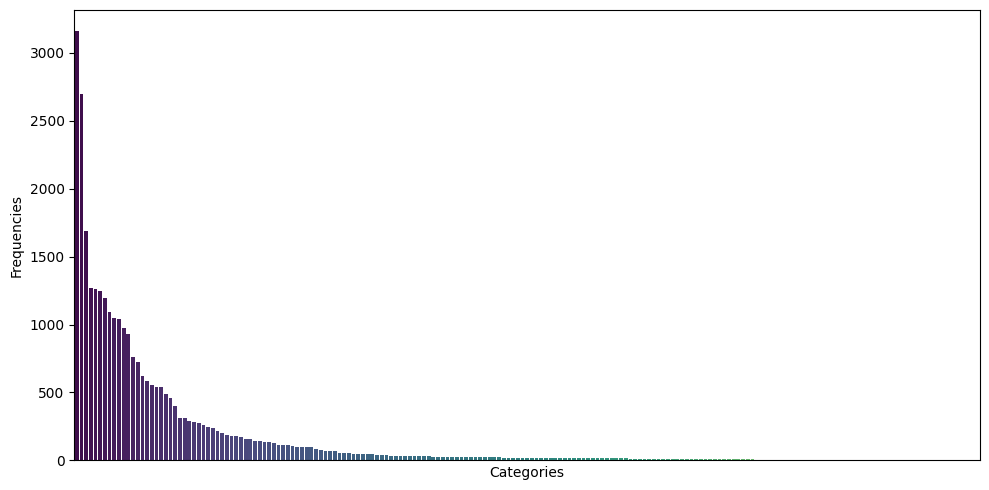

In [64]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ton Counter
#cat = Counter(cat.explode())

# Conversion en DataFrame
df_cat = pd.DataFrame(cat.items(), columns=["Categories", "Frequencies"]).sort_values("Frequencies", ascending=False)

# Barplot
plt.figure(figsize=(10, 5))
sns.barplot(data=df_cat, x="Categories", y="Frequencies", palette="viridis")


plt.xticks([])
plt.tight_layout()
plt.show()

/var/folders/4m/_y65_yfx68b53909_pvhthr40000gn/T/ipykernel_22133/3549169995.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


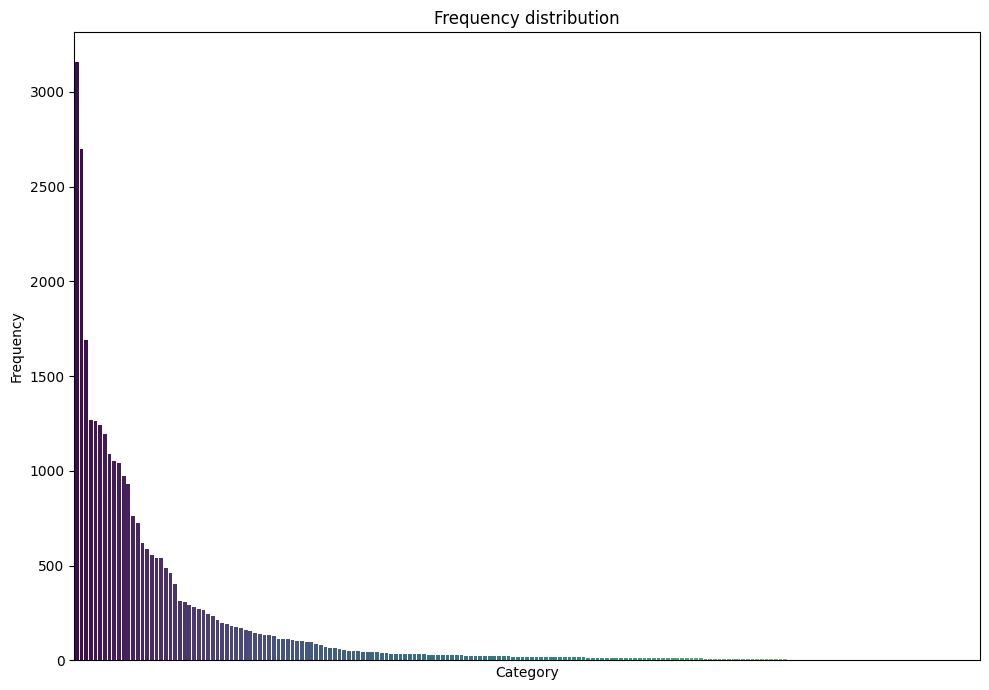

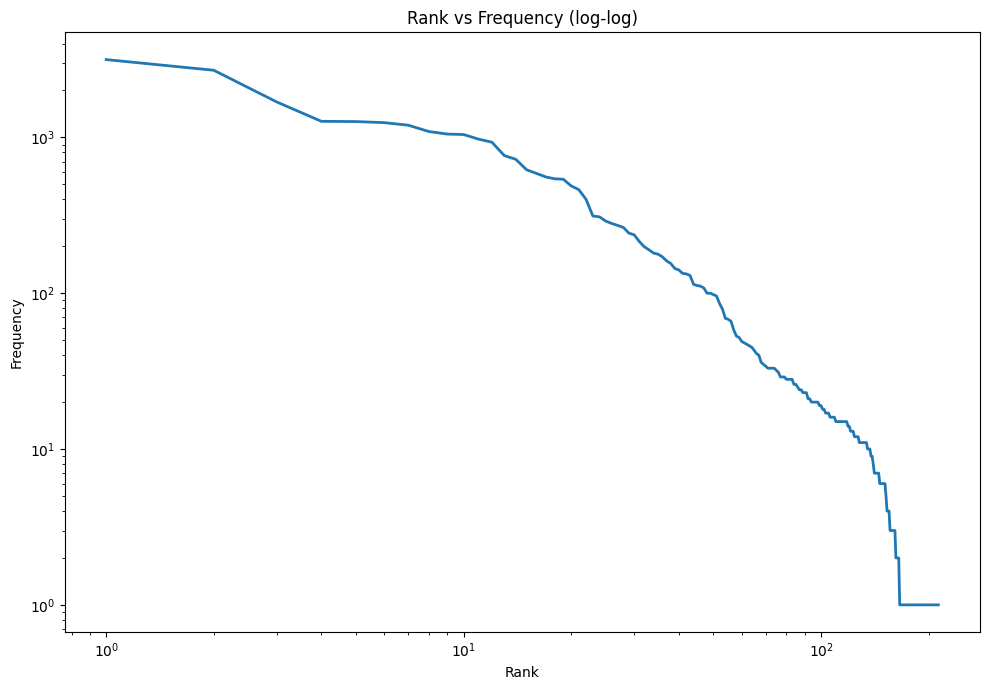

In [72]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Convert Counter to DataFrame
df_cat = (
    pd.DataFrame(cat.items(), columns=["Category", "Frequency"])
    .sort_values("Frequency", ascending=False)
)

# Add Rank column (required for line plot)
df_cat["Rank"] = range(1, len(df_cat) + 1)


# ============================
# Figure 1 — Barplot
# ============================

plt.figure(figsize=(10,7))

sns.barplot(
    data=df_cat,
    x="Category",
    y="Frequency",
    palette="viridis"
)

plt.title("Frequency distribution")
plt.xticks([])

plt.tight_layout()

plt.savefig("frequency_barplot.png", dpi=300)

plt.show()



# ============================
# Figure 2 — Log-log lineplot
# ============================

plt.figure(figsize=(10,7))

sns.lineplot(
    data=df_cat,
    x="Rank",
    y="Frequency",
    linewidth=2
)

plt.xscale("log")
plt.yscale("log")

plt.title("Rank vs Frequency (log-log)")
plt.xlabel("Rank")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("zipf_loglog.png", dpi=300)

plt.show()

/var/folders/4m/_y65_yfx68b53909_pvhthr40000gn/T/ipykernel_22133/1902710934.py:73: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


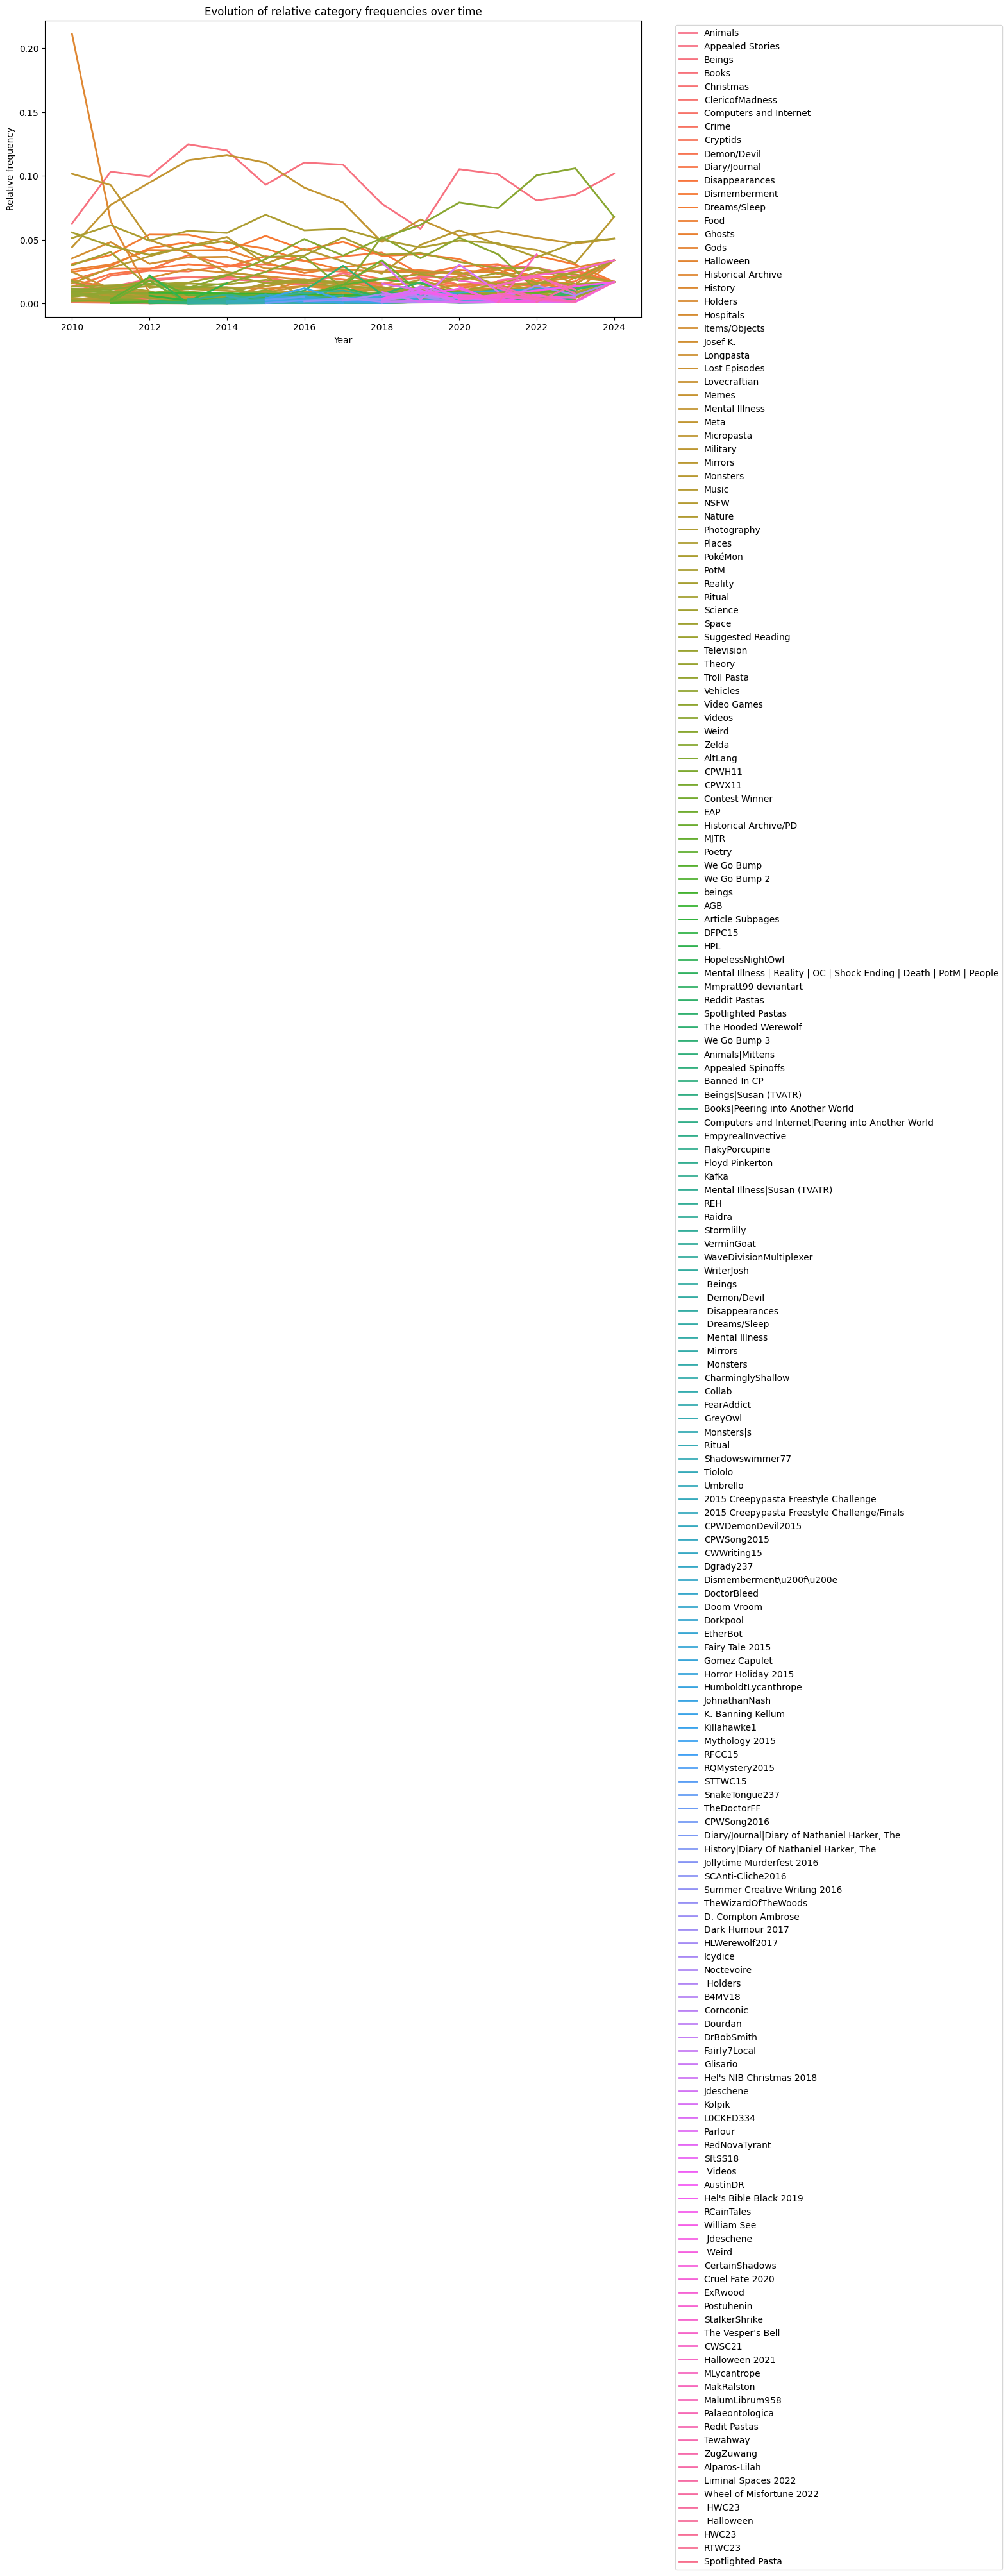

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# =========================
# 1. Convert Category column from string → list
# =========================

df["Category"] = df["Category"].apply(ast.literal_eval)

# =========================
# 2. Explode categories
# =========================

df_exp = df.explode("Category")

# =========================
# 3. Choose time variable
# =========================

# Option A — use real date
df_exp["date"] = pd.to_datetime(df_exp["date"])
df_exp["year"] = df_exp["date"].dt.year

# Option B — use Date_Num instead
# df_exp["year"] = df_exp["Date_Num"]


# =========================
# 4. Compute counts per year and category
# =========================

counts = (
    df_exp
    .groupby(["year", "Category"])
    .size()
    .reset_index(name="count")
)

# =========================
# 5. Compute relative frequencies
# =========================

counts["relative_frequency"] = (
    counts["count"] /
    counts.groupby("year")["count"].transform("sum")
)


# =========================
# 6. Plot
# =========================

plt.figure(figsize=(12,6))

sns.lineplot(
    data=counts,
    x="year",
    y="relative_frequency",
    hue="Category",
    linewidth=2
)

plt.title("Evolution of relative category frequencies over time")

plt.ylabel("Relative frequency")

plt.xlabel("Year")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()

plt.show()

In [1]:
import os 
os.listdir('/Users/rolly/Documents/10-19_Université_et_scolarité/CultureLab_papier/output')

['archive_proportions.pdf', 'archive_proportions.csv']